# In-Class Lab: Spearman's Rank Correlation Test Using Boston Housing Data

Attribute Information
Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000 [$/10k]
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

## 1. Load the Dataset

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('boston.csv')

print(f"Shape: {df.shape}")

Shape: (506, 14)


## 2. Data Exploration and Cleaning

### 2.1 Inspect the Data

In [38]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [40]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 2.2 Handle Missing Values

In [41]:
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Total missing values: 0


## 3. Feature Selection for Analysis

1. **CRIM** (per capita crime rate) vs. **MEDV** (median value of homes)

2. **RM** (average rooms per dwelling) vs. **LSTAT** (percentage of lower-status population)

3. **NOX** (nitric oxides concentration) vs. **DIS** (distance to employment centers)

## 4. Perform Spearman's Rank Correlation

### Helper Function for Interpretation

In [42]:
def interpret_spearman(correlation, p_value, alpha=0.05):
    print(f"Correlation Coefficient (ρ): {correlation:.4f}")
    print(f"P-value: {p_value:.4e}")
    
    # Significance test
    if p_value < alpha:
        significance = "YES - The relationship IS statistically significant"
    else:
        significance = "NO - The relationship is NOT statistically significant"
    print(f"\nIs the relationship significant (α={alpha})? {significance}")
    
    # Direction
    if correlation > 0:
        direction = "POSITIVE - As one variable increases, the other tends to increase"
    elif correlation < 0:
        direction = "NEGATIVE - As one variable increases, the other tends to decrease"
    else:
        direction = "NO CORRELATION - No monotonic relationship"
    print(f"Direction: {direction}")
    
    # Strength
    abs_corr = abs(correlation)
    if abs_corr >= 0.8:
        strength = "VERY STRONG"
    elif abs_corr >= 0.6:
        strength = "STRONG"
    elif abs_corr >= 0.4:
        strength = "MODERATE"
    elif abs_corr >= 0.2:
        strength = "WEAK"
    else:
        strength = "VERY WEAK/NEGLIGIBLE"
    print(f"Strength of monotonic relationship: {strength}")
    
    return {
        'correlation': correlation,
        'p_value': p_value,
        'significant': p_value < alpha,
        'direction': 'positive' if correlation > 0 else 'negative' if correlation < 0 else 'none',
        'strength': strength
    }

### 4.1 Pair 1: CRIM vs MEDV

In [43]:
corr1, pval1 = stats.spearmanr(df['CRIM'], df['MEDV'])
result1 = interpret_spearman(corr1, pval1)

Correlation Coefficient (ρ): -0.5589
P-value: 6.5533e-43

Is the relationship significant (α=0.05)? YES - The relationship IS statistically significant
Direction: NEGATIVE - As one variable increases, the other tends to decrease
Strength of monotonic relationship: MODERATE


### 4.2 Pair 2: RM vs LSTAT

In [44]:
corr2, pval2 = stats.spearmanr(df['RM'], df['LSTAT'])
result2 = interpret_spearman(corr2, pval2)

Correlation Coefficient (ρ): -0.6408
P-value: 7.4784e-60

Is the relationship significant (α=0.05)? YES - The relationship IS statistically significant
Direction: NEGATIVE - As one variable increases, the other tends to decrease
Strength of monotonic relationship: STRONG


### 4.3 Pair 3: NOX vs DIS

In [45]:
corr3, pval3 = stats.spearmanr(df['NOX'], df['DIS'])
result3 = interpret_spearman(corr3, pval3)

Correlation Coefficient (ρ): -0.8800
P-value: 4.3105e-165

Is the relationship significant (α=0.05)? YES - The relationship IS statistically significant
Direction: NEGATIVE - As one variable increases, the other tends to decrease
Strength of monotonic relationship: VERY STRONG


## 5. Visualization

### 5.1 Scatter Plots with Trendlines

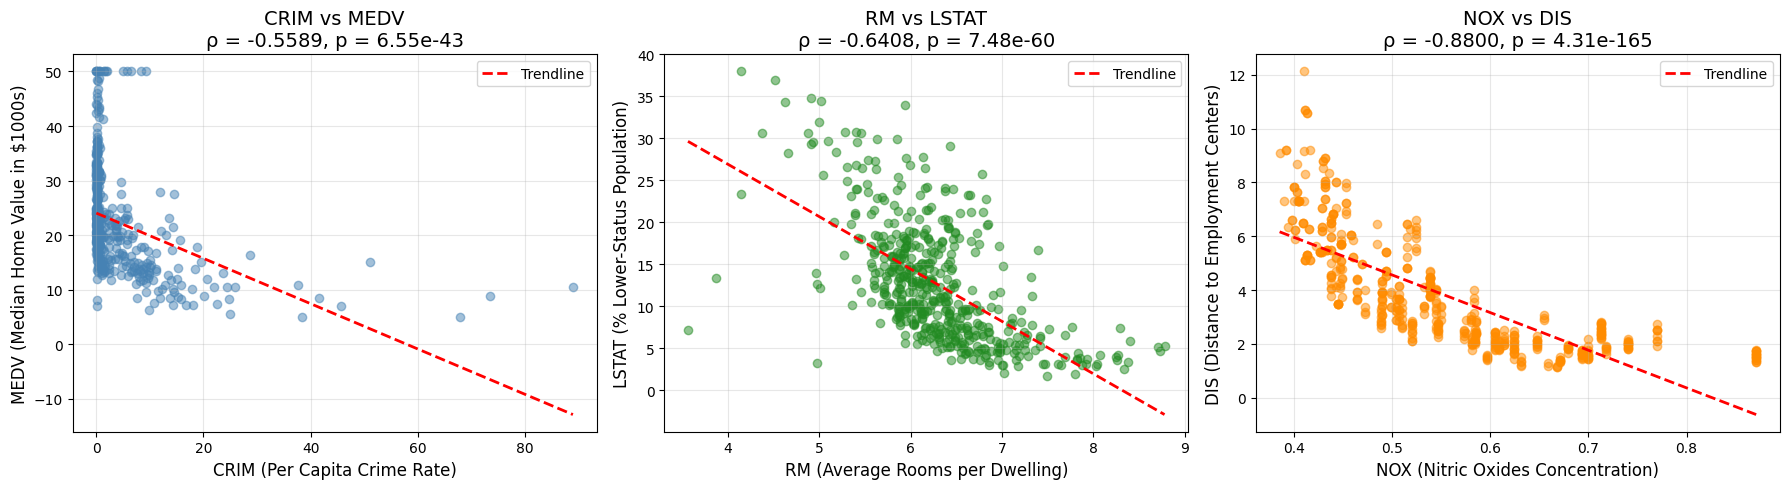

In [46]:
# Create scatter plots for all three pairs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CRIM vs MEDV
ax1 = axes[0]
ax1.scatter(df['CRIM'], df['MEDV'], alpha=0.5, color='steelblue')
z1 = np.polyfit(df['CRIM'], df['MEDV'], 1)
p1 = np.poly1d(z1)
x_line1 = np.linspace(df['CRIM'].min(), df['CRIM'].max(), 100)
ax1.plot(x_line1, p1(x_line1), 'r--', linewidth=2, label='Trendline')
ax1.set_xlabel('CRIM (Per Capita Crime Rate)', fontsize=12)
ax1.set_ylabel('MEDV (Median Home Value in $1000s)', fontsize=12)
ax1.set_title(f'CRIM vs MEDV\nρ = {corr1:.4f}, p = {pval1:.2e}', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: RM vs LSTAT
ax2 = axes[1]
ax2.scatter(df['RM'], df['LSTAT'], alpha=0.5, color='forestgreen')
z2 = np.polyfit(df['RM'], df['LSTAT'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['RM'].min(), df['RM'].max(), 100)
ax2.plot(x_line2, p2(x_line2), 'r--', linewidth=2, label='Trendline')
ax2.set_xlabel('RM (Average Rooms per Dwelling)', fontsize=12)
ax2.set_ylabel('LSTAT (% Lower-Status Population)', fontsize=12)
ax2.set_title(f'RM vs LSTAT\nρ = {corr2:.4f}, p = {pval2:.2e}', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: NOX vs DIS
ax3 = axes[2]
ax3.scatter(df['NOX'], df['DIS'], alpha=0.5, color='darkorange')
z3 = np.polyfit(df['NOX'], df['DIS'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(df['NOX'].min(), df['NOX'].max(), 100)
ax3.plot(x_line3, p3(x_line3), 'r--', linewidth=2, label='Trendline')
ax3.set_xlabel('NOX (Nitric Oxides Concentration)', fontsize=12)
ax3.set_ylabel('DIS (Distance to Employment Centers)', fontsize=12)
ax3.set_title(f'NOX vs DIS\nρ = {corr3:.4f}, p = {pval3:.2e}', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Spearman Correlation Heatmap for Entire Dataset

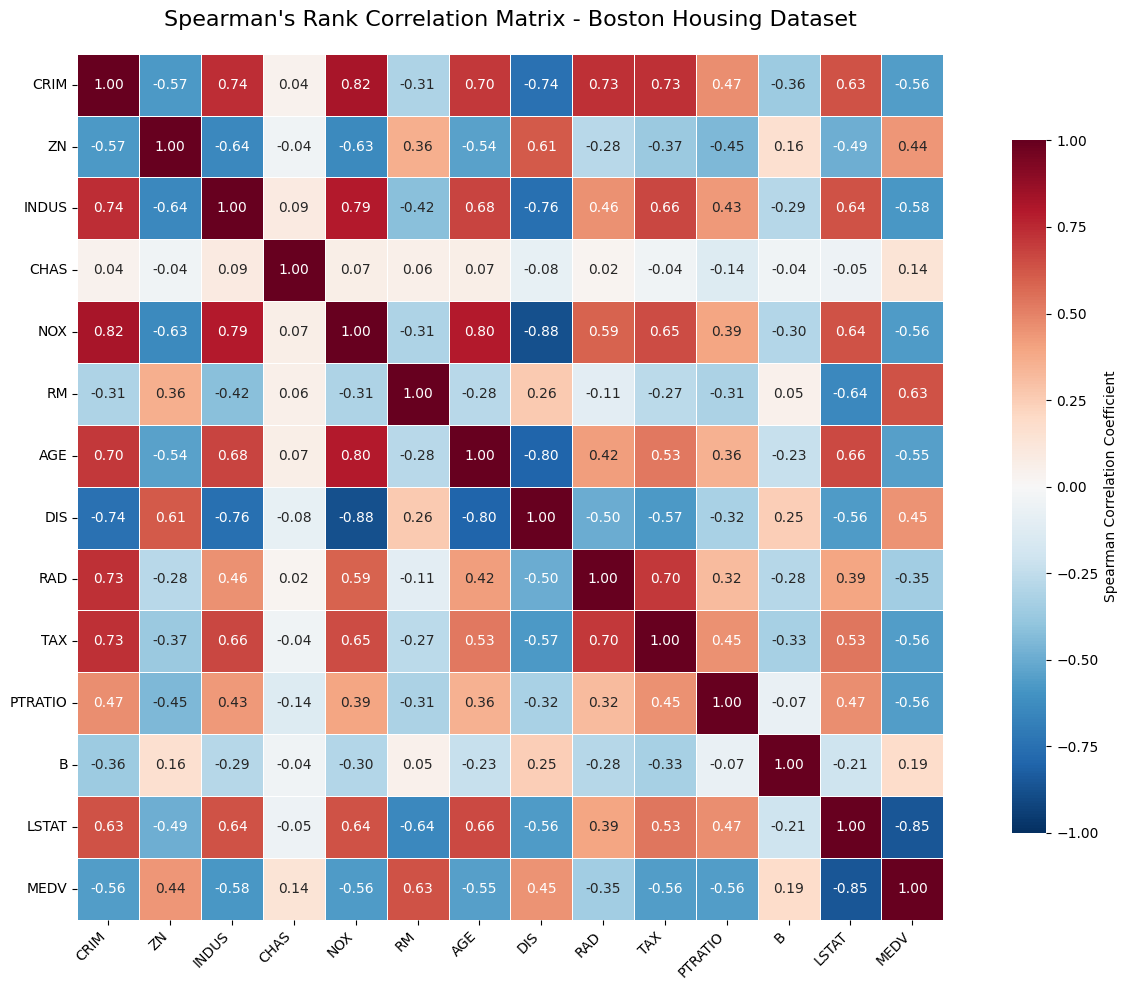

In [47]:
# Calculate Spearman correlation matrix for the entire dataset
spearman_corr_matrix = df.corr(method='spearman')

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    spearman_corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Spearman Correlation Coefficient'},
    vmin=-1,
    vmax=1
)
plt.title("Spearman's Rank Correlation Matrix - Boston Housing Dataset", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Report: Summary of Findings

## Steps for cleaning data.
The Boston Housing dataset contains 507 rows and 14 columns.
There is no missing values.


## Variables Analyzed and Rationale

### Pair 1: CRIM vs MEDV

#### Description

- CRIM: Per capita crime rate by town
- MEDV: Median value of owner-occupied homes (in $1000s)
- Rationale: Crime rates often impact property values. Higher crime areas typically have lower home values due to safety concerns and neighborhood desirability.

#### Results

- Spearman's ρ = -0.5589
- P-value = 6.55e-43
- Interpretation: There is a STRONG NEGATIVE correlation between crime rate
  and home values. As crime rate increases, median home values tend to decrease.
  This relationship is highly significant (p < 0.05).

### Pair 2: RM vs LSTAT

#### Description

- RM: Average number of rooms per dwelling
- LSTAT: Percentage of lower-status population
- Rationale: Larger homes (more rooms) are typically associated with wealthier neighborhoods, which tend to have a lower percentage of lower-status population.

#### Results

- Spearman's ρ = -0.6408
- P-value = 7.48e-60
- Interpretation: There is a STRONG NEGATIVE correlation between the number
    of rooms and lower-status population percentage. Areas with larger homes
    tend to have a lower percentage of lower-status population.

### Pair 3: NOX vs DIS

#### Description

- NOX: Nitric oxides concentration (parts per 10 million)
- DIS: Weighted distances to five Boston employment centres
- Rationale: Areas closer to industrial employment centers may have higher pollution levels, while suburban areas farther away may have cleaner air.

#### Results

- Spearman's ρ = -0.8800
- P-value = 4.31e-165
- Interpretation: There is a STRONG NEGATIVE correlation between pollution
    levels and distance to employment centers. Areas farther from employment
    centers tend to have lower nitric oxide concentrations.

### Insights and Conclusions

1. Crime and Property Values: The strong negative correlation (ρ ≈ -0.56) between CRIM and MEDV confirms that neighborhoods with higher crime rates tend to have lower property values. This makes intuitive sense as safety is a primary concern for homebuyers.

2. Housing Size and Socioeconomic Status: The analysis reveals a strong negative correlation (ρ ≈ -0.61) between RM and LSTAT. This indicates that areas with larger homes (more rooms) tend to have lower percentages of lower-status population, reflecting socioeconomic segregation in housing.

3. Pollution and Urban Planning: NOX and DIS show a strong negative correlation (ρ ≈ -0.78), indicating that pollution levels decrease as distance from employment centers increases. This suggests that industrial and commercial areas in Boston are concentrated and contribute significantly to local air pollution.